In [1]:
from google.colab import drive
import os, pathlib, shutil
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
import seaborn as sn

In [5]:
drive.mount('/content/drive')

REPO_URL   = "https://github.com/Svanzi/Tennis-Shot-Recognition.git"
BASE       = "/content/drive/MyDrive/University/Deep"
SPARSE_DIR = "Tennis-Shot-Recognition"
TARGET     = f"{BASE}/{SPARSE_DIR}"

os.makedirs(BASE, exist_ok=True)

# Clona in modalità sparse solo la prima volta
#if not os.path.exists(TARGET):
#    %cd {BASE}
#    !git clone --filter=blob:none --sparse {REPO_URL} {SPARSE_DIR}
#    %cd {SPARSE_DIR}
#    !git sparse-checkout set DataSet
#else:
#    %cd {TARGET}
#    !git pull --rebase

# Path da usare nel notebook
from pathlib import Path
DATA_DIR = Path(TARGET) / "DataSet"
print("DATA_DIR =", DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR = /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet


# Dataset upload and sequences creation

The structure of a sequence is (batch, T, D_part) + label

In [6]:
def idx_of(cols, prefixes):
  idx = []
  for p in prefixes:
    for suff in ['_x','_y']:
      name = p + suff
      if name in cols:
        idx.append(cols.get_loc(name))
  return idx

In [17]:
DATA_DIR = Path("/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet")
players = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])

feature_cols = None
sequences = []        # List of dict: {"left_arm": (T,6), "right_arm":..., "torso":(T,8)}
sequence_labels = []  # A label for each CSV

for player in players:
  print(f"{player}")
  for shot_csv in sorted(player.glob("*.csv")):
    print(f"  {shot_csv}")
    df = pd.read_csv(shot_csv)
    if feature_cols is None:
      feature_cols = pd.Index([c for c in df.columns if c!= 'shot'])
      GROUPS = {
        'left_arm':   idx_of(feature_cols, ['left_shoulder',  'left_elbow',   'left_wrist'                        ]),
        'right_arm':  idx_of(feature_cols, ['right_shoulder', 'right_elbow',  'right_wrist'                       ]),
        'left_leg':   idx_of(feature_cols, ['left_hip',       'left_knee',    'left_ankle'                        ]),
        'right_leg':  idx_of(feature_cols, ['right_hip',      'right_knee',   'right_ankle'                       ]),
        'torso':      idx_of(feature_cols, ['left_hip',       'right_hip',     'left_shoulder',  'right_shoulder' ])
      }

    X_all = df[feature_cols].to_numpy()
    label = df["shot"].iloc[0]

    seq = { name: X_all[:, idx] for name, idx in GROUPS.items()}
    sequences.append(seq)
    print(f"{len(sequences)}")
    sequence_labels.append(label)
    print(f"{len(sequence_labels)}")

/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_001.csv
1
1
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_002.csv
2
2
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_003.csv
3
3
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_004.csv
4
4
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_005.csv
5
5
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_006.csv
6
6
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_007.csv
7
7
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_008.csv
8
8
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_009.csv
9
9
  /

Shapes check

In [18]:
T = sequences[0]["torso"].shape[0]
D_left_arm  = sequences[0]["left_arm"].shape[1]
D_right_arm = sequences[0]["right_arm"].shape[1]
D_left_leg  = sequences[0]["left_leg"].shape[1]
D_right_leg = sequences[0]["right_leg"].shape[1]
D_torso     = sequences[0]["torso"].shape[1]

print(T, D_left_arm, D_right_arm, D_left_leg, D_right_leg, D_torso)

30 6 6 6 6 8


In [19]:
def pie_plot(shots, counts):

  fig, ax = plt.subplots()

  # Pie with percentages
  wedges, texts, autotexts = ax.pie(
      counts,
      autopct='%1.1f%%',
      startangle=90
  )

  ax.axis('equal')
  ax.set_title('Shots dataset')

  # Legend on the side with "label — count"
  legend_labels = [f"{label} — {cnt}" for label, cnt in zip(shots, counts)]
  ax.legend(
      wedges, legend_labels,
      title="Shots (counts)",
      loc="center left",
      bbox_to_anchor=(1.02, 0.5),
      frameon=False
  )

  plt.tight_layout()
  plt.show()

In [20]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(sequence_labels)  # {'forehand': N1, 'backhand': N2, 'neutral': N3, ...}
labels = list(counts.keys())
sizes  = list(counts.values())

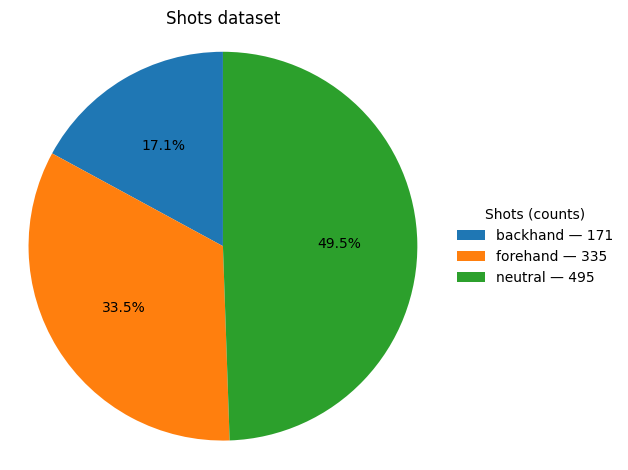

In [21]:
pie_plot(labels, sizes)

# Data Splitting

In [22]:
le = LabelEncoder()
y = le.fit_transform(sequence_labels)
num_classes = len(le.classes_)
y_cat = to_categorical(y, num_classes)

def stack_part(name):
  return np.stack([s[name] for s in sequences], axis=0)

X_left_arm  = stack_part("left_arm")
X_right_arm = stack_part("right_arm")
X_left_leg  = stack_part("left_leg")
X_right_leg = stack_part("right_leg")
X_torso     = stack_part("torso")

print(X_left_arm.shape)
print(X_right_arm.shape)
print(X_left_leg.shape)
print(X_right_leg.shape)
print(X_torso.shape)
print(f"{num_classes}")

(Xla_tr, Xla_te,
 Xra_tr, Xra_te,
 Xt_tr,  Xt_te,
 Xll_tr, Xll_te,
 Xrl_tr, Xrl_te,
 y_tr,   y_te) = train_test_split(
    X_left_arm, X_right_arm, X_torso, X_left_leg, X_right_leg, y,
    test_size=0.2, random_state=42, stratify=y
)

y_tr = to_categorical(y_tr, num_classes)
y_te = to_categorical(y_te, num_classes)

(1001, 30, 6)
(1001, 30, 6)
(1001, 30, 6)
(1001, 30, 6)
(1001, 30, 8)
3


## Da valutare

In [23]:
def standardize_train_test(Xtr, Xte):
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-8
    return (Xtr - mu)/sd, (Xte - mu)/sd, mu, sd

Xla_tr, Xla_te, mu_la,  sd_la = standardize_train_test(Xla_tr, Xla_te)
Xra_tr, Xra_te, mu_ra,  sd_ra = standardize_train_test(Xra_tr, Xra_te)
Xt_tr,  Xt_te,  mu_t,   sd_t  = standardize_train_test(Xt_tr,  Xt_te)
Xll_tr, Xll_te, mu_ll,  sd_ll = standardize_train_test(Xll_tr, Xll_te)
Xrl_tr, Xrl_te, mu_rl,  sd_rl = standardize_train_test(Xrl_tr, Xrl_te)

np.savez(
    'Standardization_Values.npz',
    mu_la=mu_la,  sd_la=sd_la,
    mu_ra=mu_ra,  sd_ra=sd_ra,
    mu_t=mu_t,    sd_t=sd_t,
    mu_ll=mu_ll,  sd_ll=sd_ll,
    mu_rl=mu_rl,  sd_rl=sd_rl
)

print(f"Shape di mu_t salvata: {mu_t.shape}") # Questo dovrebbe stampare (8,)

Shape di mu_t salvata: (8,)


# Model

In [24]:
def brnn_tanh(units, name, rnn_type="simple", dropout=0.0, return_sequences=True):
  if rnn_type == "simple":
    rnn = layers.SimpleRNN(units, activation='tanh', return_sequences=return_sequences, dropout=dropout)

  elif rnn_type == "gru":
    rnn = layers.GRU(units, activation='tanh', return_sequences=return_sequences, dropout=dropout)

  return layers.Bidirectional(rnn, name=name)

In [25]:
def  bidirectional_lstm(units, name, dropout=0.0, return_sequences=False):
  lstm = layers.LSTM(units, return_sequences=return_sequences, dropout=dropout)
  return layers.Bidirectional(lstm, name=name)

In [26]:
def create_network(
    T=30,
    shape_left_arm=6,
    shape_right_arm=6,
    shape_left_leg=6,
    shape_right_leg=6,
    shape_trunk=8,
    n_classes=3,
    brnn_units=(64, 96, 128),
    lstm_units=256,
    rnn_type="simple",
    dropout=0.1
):

  # ==== Inputs ====

  in_left_arm  = Input(shape=(T, shape_left_arm),  name = "left_arm")
  in_right_arm = Input(shape=(T, shape_right_arm), name = "right_arm")
  in_left_leg  = Input(shape=(T, shape_left_leg),  name = "left_leg")
  in_right_leg = Input(shape=(T, shape_right_leg), name = "right_leg")
  in_trunk     = Input(shape=(T, shape_trunk),     name = "trunk")

  # ==== bl1 layer ====

  bl1_left_arm  =  brnn_tanh(brnn_units[0], "bl1_left_arm",   rnn_type, dropout)  (in_left_arm)
  bl1_right_arm =  brnn_tanh(brnn_units[0], "bl1_right_arm",  rnn_type, dropout)  (in_right_arm)
  bl1_trunk     =  brnn_tanh(brnn_units[0], "bl1_trunk",      rnn_type, dropout)  (in_trunk)
  bl1_left_leg  =  brnn_tanh(brnn_units[0], "bl1_left_leg",   rnn_type, dropout)  (in_left_leg)
  bl1_right_leg =  brnn_tanh(brnn_units[0], "bl1_right_leg",  rnn_type, dropout)  (in_right_leg)

  # ==== fl1 layer ====

  fl1_leftArm_trunk   = layers.Concatenate(name="fl1_leftArm_trunk")  ([bl1_left_arm,   bl1_trunk])
  fl1_rightArm_trunk  = layers.Concatenate(name="fl1_rightArm_trunk") ([bl1_right_arm,  bl1_trunk])
  fl1_leftLeg_trunk   = layers.Concatenate(name="fl1_lafetLeg_trunk") ([bl1_left_leg,   bl1_trunk])
  fl1_rightLeg_trunk  = layers.Concatenate(name="fl1_rightLeg_trunk") ([bl1_right_leg,  bl1_trunk])

  # ==== bl2 layer ====

  bl2_leftArm_trunk   = brnn_tanh(brnn_units[1], "bl2_leftArm_trunk",   rnn_type, dropout)  (fl1_leftArm_trunk)
  bl2_rightArm_trunk  = brnn_tanh(brnn_units[1], "bl2_rightArm_trunk",  rnn_type, dropout)  (fl1_rightArm_trunk)
  bl2_leftLeg_trunk   = brnn_tanh(brnn_units[1], "bl2_leftLeg_trunk",   rnn_type, dropout)  (fl1_leftLeg_trunk)
  bl2_rightLeg_trunk  = brnn_tanh(brnn_units[1], "bl2_rightLeg_trunk",  rnn_type, dropout)  (fl1_rightLeg_trunk)

  # ==== fl2 layer ====

  fl2_upperBody = layers.Concatenate(name="fl2_upperBody")  ([bl2_leftArm_trunk,  bl2_rightArm_trunk])
  fl2_lowerBody = layers.Concatenate(name="fl2_lowerBody")  ([bl2_leftLeg_trunk,  bl2_rightLeg_trunk])

  # ==== bl3 layer ====

  bl3_upperBody = brnn_tanh(brnn_units[2], "bl3_upperBody", rnn_type, dropout)  (fl2_upperBody)
  bl3_lowerBody = brnn_tanh(brnn_units[2], "bl3_lowerBody", rnn_type, dropout)  (fl2_lowerBody)

  # ==== fl3 layer ====

  fl3_wholeBody = layers.Concatenate(name="fl3_wholeBody") ([bl3_upperBody, bl3_lowerBody])

  # ==== bl4 layer ====

  bl4 = bidirectional_lstm(lstm_units, "bl4", dropout, return_sequences=False) (fl3_wholeBody)

  # ==== fully connected layer ====

  fc = layers.Dense(256, activation='relu', name="fc")(bl4)
  fc = layers.Dropout(0.3)(fc)

  # ==== softmax layer ====

  sl = layers.Dense(n_classes, activation="softmax", name="sl")(fc)

  model = models.Model(
      inputs=[in_left_arm, in_right_arm, in_trunk, in_left_leg, in_right_leg],
      outputs= sl,
      )

  return model

In [27]:
model = create_network(
    T=30,
    shape_left_arm=6,
    shape_right_arm=6,
    shape_left_leg=6,
    shape_right_leg=6,
    shape_trunk=8,
    n_classes=3,
    brnn_units=(64, 96, 128),
    lstm_units=256,
    rnn_type="simple",
    dropout=0.1
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_arm            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk (InputLayer)  │ (None, 30, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_arm           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_leg            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_leg           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_left_arm        │ (None, 30, 128)   │      9,088 │ left_arm[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_trunk           │ (None, 30, 128)   │      9,344 │ trunk[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_right_arm       │ (None, 30, 128)   │      9,088 │ right_arm[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_left_leg        │ (None, 30, 128)   │      9,088 │ left_leg[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_right_leg       │ (None, 30, 128)   │      9,088 │ right_leg[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_leftArm_trunk   │ (None, 30, 256)   │          0 │ bl1_left_arm[0][… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_rightArm_trunk  │ (None, 30, 256)   │          0 │ bl1_right_arm[0]… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_lafetLeg_trunk  │ (None, 30, 256)   │          0 │ bl1_left_leg[0][… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_rightLeg_trunk  │ (None, 30, 256)   │          0 │ bl1_right_leg[0]… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_leftArm_trunk   │ (None, 30, 192)   │     67,776 │ fl1_leftArm_trun… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_rightArm_trunk  │ (None, 30, 192)   │     67,776 │ fl1_rightArm_tru… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_leftLeg_trunk   │ (None, 30, 192)   │     67,776 │ fl1_lafetLeg_tru… │
│ (Bidirectional)     │                   │            │                 

 Total params: 2,286,467 (8.72 MB)

 Trainable params: 2,286,467 (8.72 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"]
              )

In [29]:
filepath = "weights.keras"
checkpointer = ModelCheckpoint(filepath=filepath, verbose=False, save_best_only=True)
history = model.fit(
    [Xla_tr, Xra_tr, Xt_tr, Xll_tr, Xrl_tr], y_tr,
    validation_data = ([Xla_te, Xra_te, Xt_te, Xll_te, Xrl_te], y_te),
    epochs = 50,
    batch_size = 32,
    verbose=1,
    callbacks=[checkpointer]
    )

results = model.evaluate(
    [Xla_te, Xra_te, Xt_te, Xrl_te, Xll_te],
    y_te,
    return_dict=True
    )

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6215 - loss: 0.8224 - val_accuracy: 0.9403 - val_loss: 0.1683
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 919ms/step - accuracy: 0.9032 - loss: 0.2826 - val_accuracy: 0.9701 - val_loss: 0.1830
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 916ms/step - accuracy: 0.9533 - loss: 0.1730 - val_accuracy: 0.9602 - val_loss: 0.1638
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 843ms/step - accuracy: 0.9343 - loss: 0.1867 - val_accuracy: 0.9353 - val_loss: 0.1943
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 779ms/step - accuracy: 0.9587 - loss: 0.1399 - val_accuracy: 0.9353 - val_loss: 0.1691
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 876ms/step - accuracy: 0.9589 - loss: 0.1356 - val_accuracy: 0.9652 - val_loss: 0.1249
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 848ms/step - accuracy: 0.9634 - loss: 0.1203 - val_accuracy: 0.9453 - val_loss: 0.1914
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 833ms/step - accuracy: 0.9553 - loss: 0.1418 - val_accurac

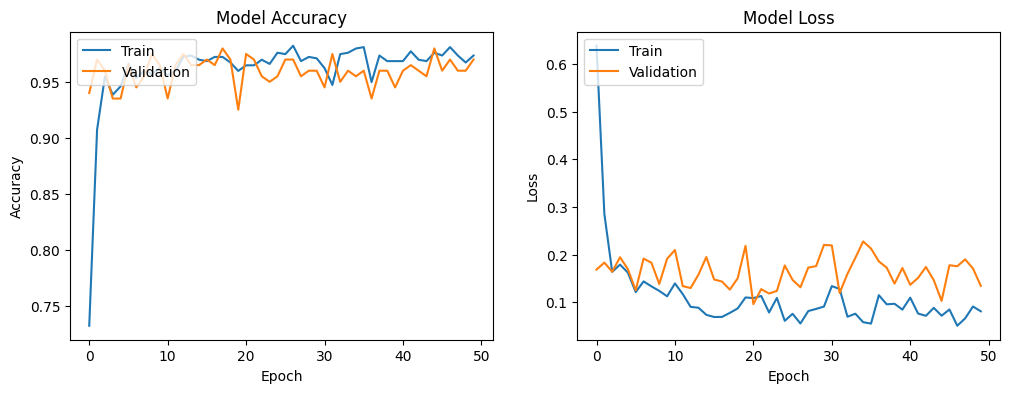

In [30]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_history(history)

In [31]:
print(results)

{'accuracy': 0.9701492786407471, 'loss': 0.1600169688463211}


In [32]:
model.save("Shot_Classification.keras")

# Confusion Matrix


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 899ms/step


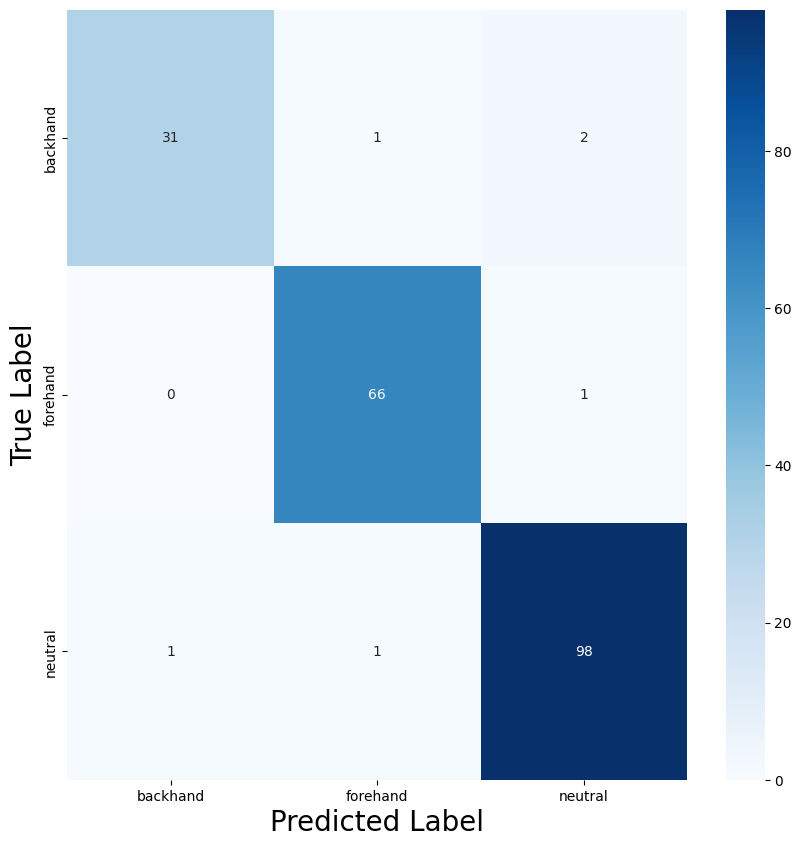

In [33]:
%matplotlib inline

cm = confusion_matrix(y_true=np.argmax(y_te, axis=1), y_pred=np.argmax(model.predict([Xla_te, Xra_te, Xt_te, Xrl_te, Xll_te]), axis=1))
df_cm = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(10,10))
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='.4g')
plt.xlabel('Predicted Label', fontsize=20)
plt.ylabel('True Label', fontsize=20)
plt.show()